<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/ACAD_EXERCISE_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTED LIBRARIES

In [53]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import PowerTransformer


In [54]:
df = pd.read_csv('/content/EFIplus_medit.csv',sep=';')

**## DEFINE RESPONSE AND PREDICTOR VARIABLE**

In [55]:
 response = 'Total_sp'
predictors = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

**## HAD TO CHECK FOR VAIRALE DISTRIBUTION**

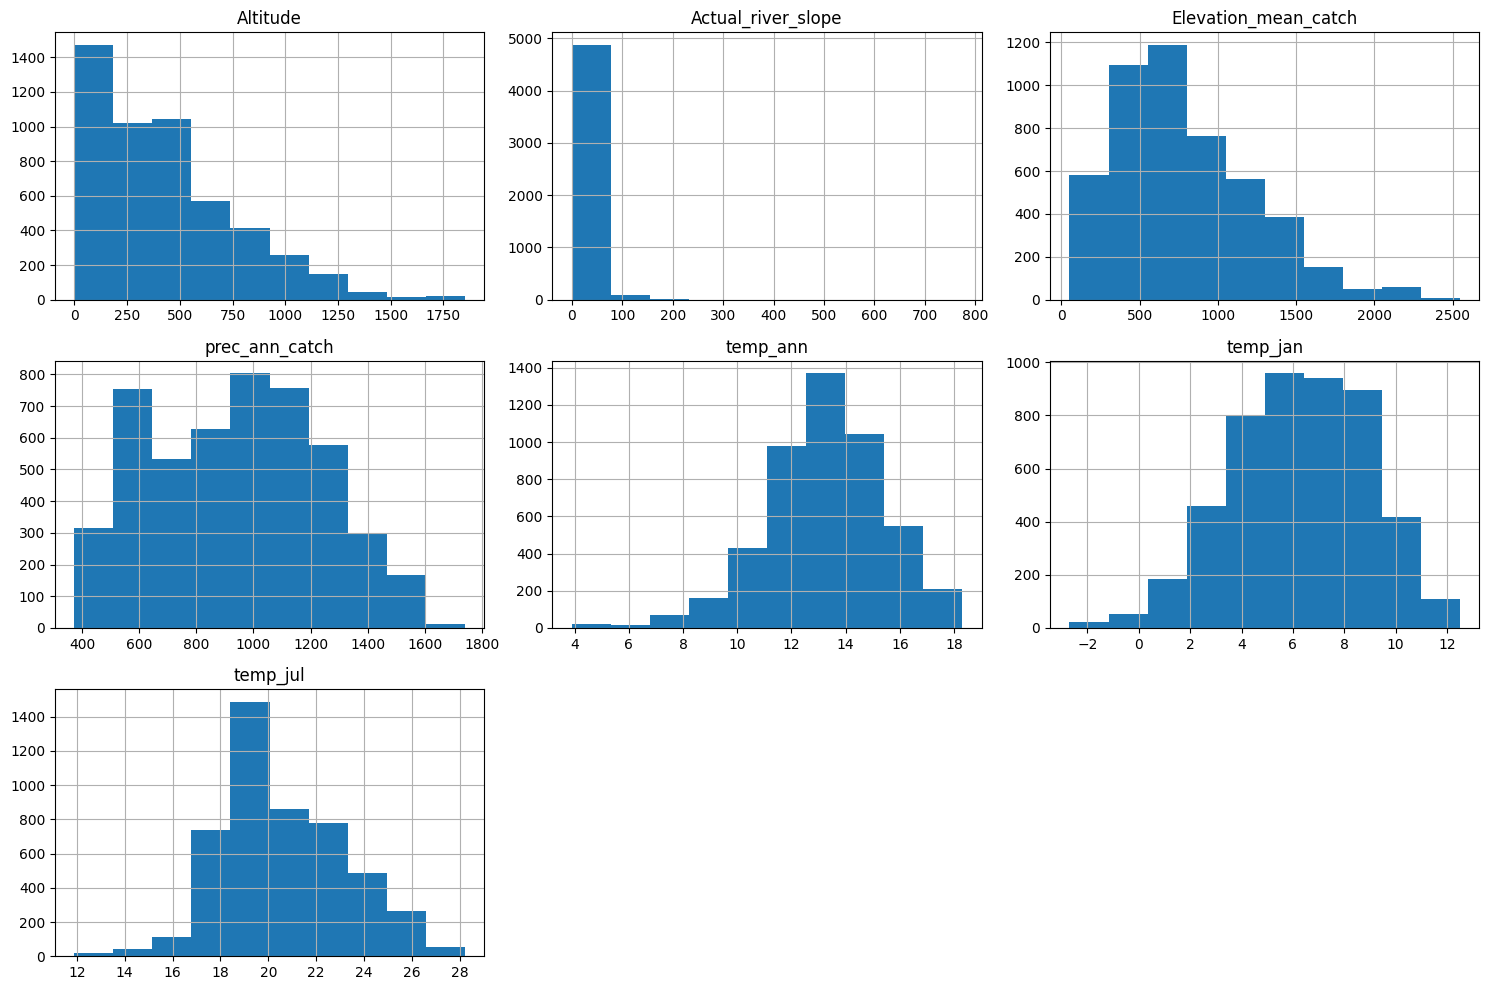

In [56]:
# Histograms
df[predictors].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

 **##TRANSFORM SKEWED VARIABLES**

In [57]:
# Add +1 to avoid log(0)
df['log_Altitude'] = np.log1p(df['Altitude'])
df['log_Actual_river_slope'] = np.log1p(df['Actual_river_slope'])
df['log_Elevation_mean_catch'] = np.log1p(df['Elevation_mean_catch'])

In [58]:
predictors_transformed = [
    'log_Altitude',
    'log_Actual_river_slope',
    'log_Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

**#SIMPLE LINEAR REGRESSIONS**

In [59]:
results = []

for var in predictors_transformed:

    formula = f"{response} ~ {var}"
    model = smf.ols(formula, data=df).fit()

    print("\n")
    print("="*60)
    print(f"Regression: {response} ~ {var}")
    print("="*60)

    print(model.summary())

    # Store results
    results.append({
        'Predictor': var,
        'Coefficient': model.params[var],
        'R_squared': model.rsquared,
        'F_statistic': model.fvalue,
        'p_value': model.pvalues[var]
    })



Regression: Total_sp ~ log_Altitude
                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     744.1
Date:                Thu, 14 May 2026   Prob (F-statistic):          7.02e-153
Time:                        20:54:48   Log-Likelihood:                -11454.
No. Observations:                5011   AIC:                         2.291e+04
Df Residuals:                    5009   BIC:                         2.292e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept 

**## Plot fitted regression**

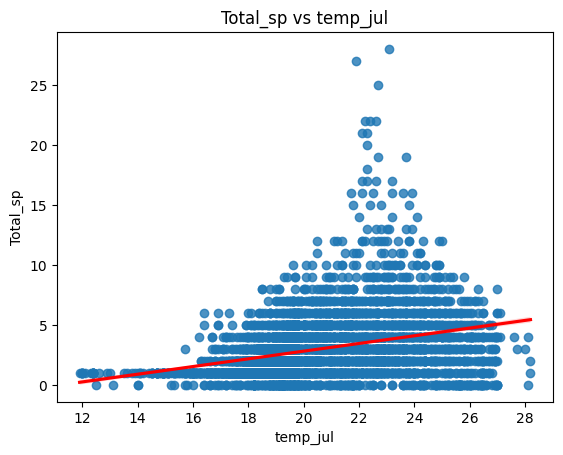

In [60]:
# Plot fitted regression
sns.regplot(x=var, y=response, data=df,
            line_kws={'color':'red'})

plt.title(f'{response} vs {var}')
plt.show()

In [61]:
results_df = pd.DataFrame(results)

print(results_df)

                  Predictor  Coefficient  R_squared  F_statistic  \
0              log_Altitude    -0.752051   0.129340   744.106274   
1    log_Actual_river_slope    -0.904492   0.132502   759.576136   
2  log_Elevation_mean_catch    -1.007497   0.058574   301.074737   
3            prec_ann_catch    -0.001319   0.023167   114.763154   
4                  temp_ann     0.388504   0.110822   603.103686   
5                  temp_jan     0.215228   0.051087   260.517520   
6                  temp_jul     0.320188   0.106434   576.382907   

         p_value  
0  7.022661e-153  
1  9.928227e-156  
2   1.778034e-65  
3   1.753155e-26  
4  1.302977e-125  
5   4.011752e-57  
6  1.975606e-120  


**## Multi linear regression**

In [62]:
formula = f"{response} ~ " + " + ".join(predictors_transformed)

multiple_model = smf.ols(formula, data=df).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     259.6
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        20:54:48   Log-Likelihood:                -10553.
No. Observations:                4819   AIC:                         2.112e+04
Df Residuals:                    4811   BIC:                         2.117e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

**##Compare Single vs Multiple Regression Coefficients**

In [63]:
multi_coef = multiple_model.params

comparison = pd.DataFrame({
    'Simple_regression_coef': results_df.set_index('Predictor')['Coefficient'],
    'Multiple_regression_coef': multi_coef.drop('Intercept')
})

print(comparison)

                          Simple_regression_coef  Multiple_regression_coef
log_Altitude                           -0.752051                 -1.012233
log_Actual_river_slope                 -0.904492                 -0.544085
log_Elevation_mean_catch               -1.007497                 -0.430508
prec_ann_catch                         -0.001319                  0.001125
temp_ann                                0.388504                  0.248480
temp_jan                                0.215228                 -0.592383
temp_jul                                0.320188                  0.272543


**##Check Multicollinearity**

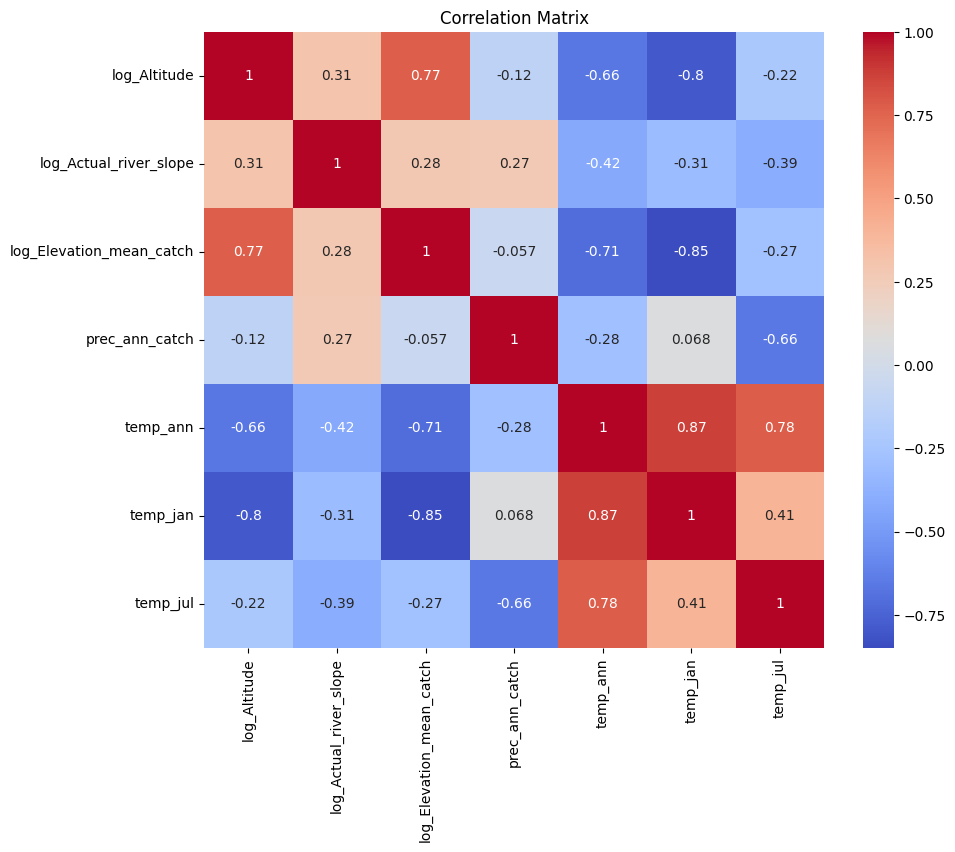

In [64]:
corr_matrix = df[predictors_transformed].corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [65]:
X = df[predictors_transformed]
X = sm.add_constant(X)
X = X.dropna() # Drop rows with NaN values after adding constant

vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

                   Variable         VIF
0                     const  725.778277
1              log_Altitude    3.388416
2    log_Actual_river_slope    1.281955
3  log_Elevation_mean_catch    4.130830
4            prec_ann_catch    2.446626
5                  temp_ann   56.554965
6                  temp_jan   27.562107
7                  temp_jul   18.869415


**##CREATE REDUCED MODEL**

In [66]:

# Keep only variables with acceptable VIF

reduced_predictors = [
    'log_Altitude',
    'log_Actual_river_slope',
    'log_Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann'
]

# Create formula
formula_reduced = (
    f"{response} ~ " +
    " + ".join(reduced_predictors)
)

# Fit reduced model
reduced_model = smf.ols(
    formula_reduced,
    data=df
).fit()

## PRINT SUMMARY**

In [67]:

print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     262.4
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.01e-248
Time:                        20:54:49   Log-Likelihood:                -10745.
No. Observations:                4819   AIC:                         2.150e+04
Df Residuals:                    4813   BIC:                         2.154e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               


**## CHECK VIF AGAIN FOR REDUCED MODEL**

In [68]:

# CHECK VIF AGAIN FOR REDUCED MODEL

X_reduced = df[reduced_predictors]

X_reduced = sm.add_constant(X_reduced)
X_reduced = X_reduced.dropna() # Drop rows with NaN values after adding constant

vif_reduced = pd.DataFrame()

vif_reduced["Variable"] = X_reduced.columns

vif_reduced["VIF"] = [
    variance_inflation_factor(
        X_reduced.values, i
    )
    for i in range(X_reduced.shape[1])
]

print(vif_reduced)

                   Variable         VIF
0                     const  713.178894
1              log_Altitude    2.980520
2    log_Actual_river_slope    1.276290
3  log_Elevation_mean_catch    3.107829
4            prec_ann_catch    1.434184
5                  temp_ann    2.993832
